In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import os
import re
import scipy.sparse
import random
import matplotlib.patches as mpatches
import h5py
import seaborn as sns

import DNA3Bit
encoder = DNA3Bit.DNA3Bit()

sc.set_figure_params(dpi=80)

%config InlineBackend.figure_format='retina'


In [ ]:
plt.rcParams['axes.grid'] = False
fontsize = 16
plt.rcParams['xtick.labelsize'] = fontsize
plt.rcParams['ytick.labelsize'] = fontsize
plt.rcParams['axes.labelsize'] = fontsize
plt.rcParams['axes.labelsize'] = fontsize
plt.rcParams['axes.titlesize'] = fontsize


In [ ]:
import importlib.util
import sys

def lazy_import(module_name, path_to_file):
    spec = importlib.util.spec_from_file_location(module_name,path_to_file)
    foo = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = foo
    spec.loader.exec_module(foo)
    return foo

utils_dir = "../../utils"
general_utils =  lazy_import("general_utils",os.path.join(utils_dir, "general_utils.py"))
anndata_utils = lazy_import("anndata_utils",os.path.join(utils_dir, "anndata_utils.py"))
plotting_functions = lazy_import("plotting_functions",os.path.join(utils_dir, "plotting_functions.py"))
thresholding_functions = lazy_import("thresholding_functions",os.path.join(utils_dir, "thresholding_functions.py"))
preprocessing_utils = lazy_import("preprocessing_utils",os.path.join(utils_dir, "preprocessing_utils.py"))
diffusion_maps = lazy_import("diffusion_maps",os.path.join(utils_dir, "diffusion_maps.py"))
gene_signatures = lazy_import("gene_signatures",os.path.join(utils_dir, "gene_signatures.py"))

from general_utils import ismember, grep, grep_exclude, read_object, write_object
from plotting_functions import plot_individual_category
from anndata_utils import marker_genes_for_cell_group, get_gene, get_genes, annotate_groups, random_adata_subset, query_region, filter_coordinates
from thresholding_functions import threshold_otsu, threshold_triangle
from preprocessing_utils import kneepoint, process_pca_results, process_pca_inflection, add_obs_names, consolidate_var_names, norm_log_transform, HVG_selection
from diffusion_maps import get_diffusion_operator_from_knn, getDiffusionComponents, plot_diffusion_components
from gene_signatures import attach_signatures_low_memory


In [ ]:
experiment_prefix = "Reyes_multiome"
intermediate_output_path = '../preprocessed/'

integrated_output = os.path.join(intermediate_output_path, 'step0_simplePreprocessing')
embedding_output = os.path.join(intermediate_output_path, 'step1_umap_annotate')

os.makedirs(embedding_output, exist_ok=True)


In [ ]:
os.listdir(integrated_output)

['multiome_PP20251110_step0_atacQC_custom.csv',
 'multiome_PP20251110_step0_BATCH_m1_SUBSET_K2ctrl_groupfilter_date20251110.h5ad',
 'multiome_PP20251110_step0_LAYER_cellbender_groupfilter_date20251110.h5ad',
 'multiome_PP20251110_step0_LAYER_raw_groupfilter_date20251110.h5ad',
 'multiome_PP20251110_step0_int_groupfilter_date20251110.h5ad',
 'multiome_PP20251110_step0_atacQC.csv',
 'multiome_PP20251110_step0_BATCH_m3_SUBSET_K2ctrl_groupfilter_date20251110.h5ad']

In [ ]:
adata = sc.read_h5ad(os.path.join(integrated_output, "Reyes_multiome_step0_int_groupfilter_date20251110.h5ad"))

### Embed batch m1

In [ ]:
selected_batch = "m1"
adata_sub = adata[adata.obs['batch'] == selected_batch,:].copy()

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


Normalizing data
Log transform with pseudocount 1


/data1/lowes/reyesj3/miniconda3/envs/seacells/lib/python3.11/site-packages/scipy/sparse/_construct.py:178: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if len(diagonals) == 0 or isscalarlike(diagonals[0]):


Highly variable gene selection with custom gene exclusion
Selecting 3000 highly variable genes using Scanpy Seurat v3
Using 3000 highly variable genes
Detecting inflection point with average smoothing window of 10 and epsilon 0.000010
Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.033095359802246094 seconds
Jaccard graph constructed in 1.1278727054595947 seconds
Running Leiden optimization
Leiden completed in 0.6565346717834473 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 2.745353937149048 seconds
Finding 10 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.14982008934020996 seconds
Jaccard graph constructed in 0.9382979869842529 seconds
Running Leiden optimization
Leiden completed in 0.3584480285644531 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 2.362788438796997 seconds


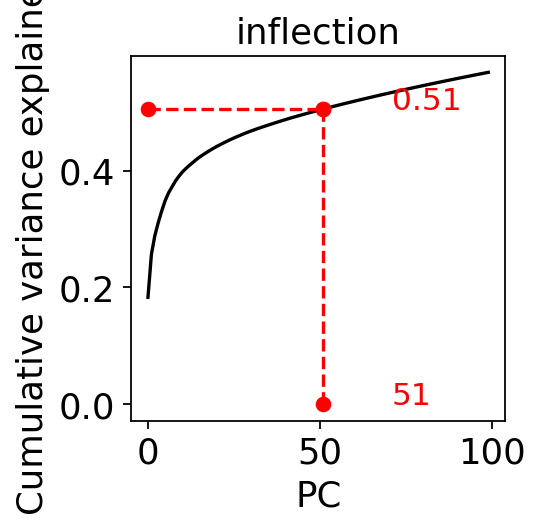

In [ ]:
layer = 'cellbender'
size_factors = 'log_lib_size_%s_all' % (layer)

adata_sub.X = adata_sub.layers['cellbender'].copy()
adata_sub = norm_log_transform(adata_sub, np.expm1(adata_sub.obs[size_factors]), [])
sc.pp.filter_cells(adata_sub, min_counts=1)
sc.pp.filter_genes(adata_sub, min_cells=1)

adata_sub = HVG_selection(adata_sub, num_HVG = 3000, exclude_genes = adata_sub.var['excluded']==True, mode='scanpy', layer='cellbender')
sc.pp.pca(adata_sub, n_comps=100, mask_var='highly_variable')
adata_sub.uns['pca_explained_variance'] = adata_sub.uns['pca']['variance_ratio']
selected_pcs, explained_var = process_pca_results(adata_sub, pca_mode = 'inflection', min_pcs = 50)

sc.pp.neighbors(adata_sub, n_neighbors=30)
sc.tl.umap(adata_sub)

communities = sc.external.tl.phenograph(adata_sub, k=30, clustering_algo = 'leiden', seed = 0, copy=True)
adata_sub.obs['pheno_30'] = pd.Categorical(communities[0])
communities = sc.external.tl.phenograph(adata_sub, k=10, clustering_algo = 'leiden', seed = 0, copy=True)
adata_sub.obs['pheno_10'] = pd.Categorical(communities[0])

In [ ]:
from tqdm import tqdm 

# Z-score and add signature scores
adata_temp = adata_sub.copy()
adata_temp.layers['zscore'] = adata_temp.X.copy()
sc.pp.scale(adata_temp, layer='zscore')
selected_signatures = ['progenitor_specific_0', 'ADM_specific_0', 'gastric_specific_0', 'tuft_specific_30', 'neuroendocrine_specific_0']
signature_names, signature_dict = attach_signatures_low_memory(adata_temp, '../../transcriptomics/signatures/', selected_signatures)

/data1/lowes/reyesj3/miniconda3/envs/seacells/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
  0%|          | 0/238 [00:00<?, ?it/s]/data1/lowes/reyesj3/miniconda3/envs/seacells/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/data1/lowes/reyesj3/miniconda3/envs/seacells/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
 18%|█▊        | 44/238 [00:00<00:00, 228.65it/s]/data1/lowes/reyesj3/miniconda3/envs/seacells/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/data1/lowes/reyesj3/miniconda3/envs/seacells/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies i

/tmp/ipykernel_592733/270642965.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = adata_temp.obs[selected_signatures + ['pheno_30']].groupby('pheno_30').agg('mean')


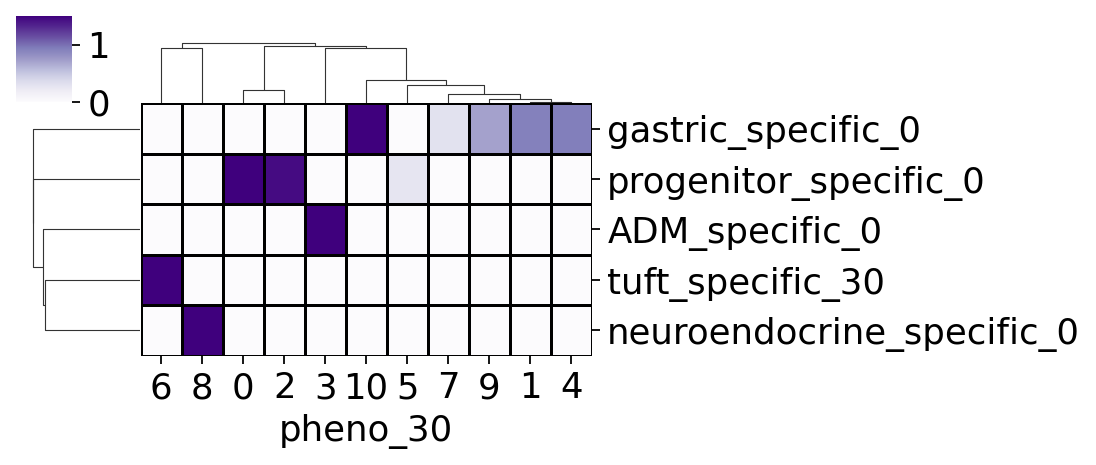

In [ ]:
df = adata_temp.obs[selected_signatures + ['pheno_30']].groupby('pheno_30').agg('mean')
df = df - df.mean(axis=0)
df = df / np.std(df, axis=0)
sns.clustermap(df.T, figsize=[7,3], method='ward', dendrogram_ratio=0.2, cmap='Purples', linewidths = 0.5, vmin=0, vmax=1.5, linecolor='black')
plt.grid(False)

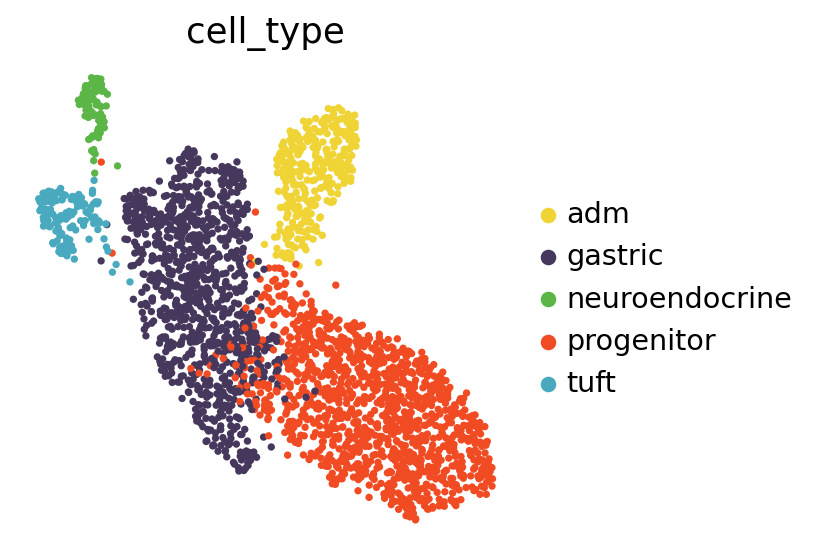

In [ ]:
cell_type = np.array(['undefined'] * adata_sub.n_obs, dtype=object)

# Selected annotation for equalized median size factor version
cell_type[ismember(adata_sub.obs['pheno_30'], [3])[1]] = 'adm'
cell_type[ismember(adata_sub.obs['pheno_30'], [6])[1]] = 'tuft'
cell_type[ismember(adata_sub.obs['pheno_30'], [8])[1]] = 'neuroendocrine'
cell_type[ismember(adata_sub.obs['pheno_30'], [0,2,5])[1]] = 'progenitor'
cell_type[ismember(adata_sub.obs['pheno_30'], [7,9,1,4,10])[1]] = 'gastric'
adata_sub.obs['cell_type'] = cell_type.copy()

cell_type_palette = ['#F0D335', '#46375C', '#5CB647', '#F04B23', '#48A9BF', 'lightgray']

sc.pl.umap(adata_sub, color='cell_type', palette = cell_type_palette, frameon=False)

In [ ]:
indices = (adata_sub.obsp['distances'] > 0).astype(np.uint8)
T, _ = get_diffusion_operator_from_knn(indices, adata_sub.obsp['distances'])
dm_res = getDiffusionComponents(T)

adata_sub.obsm['X_diff_comp'] = dm_res['EigenVectors'].to_numpy()[:,1:].copy()
adata_sub.uns['diff_comp_eigenvalues'] = dm_res['EigenValues'].to_numpy()[1:].copy()
adata_sub.obsm['diff_operator'] = dm_res['T'].copy()


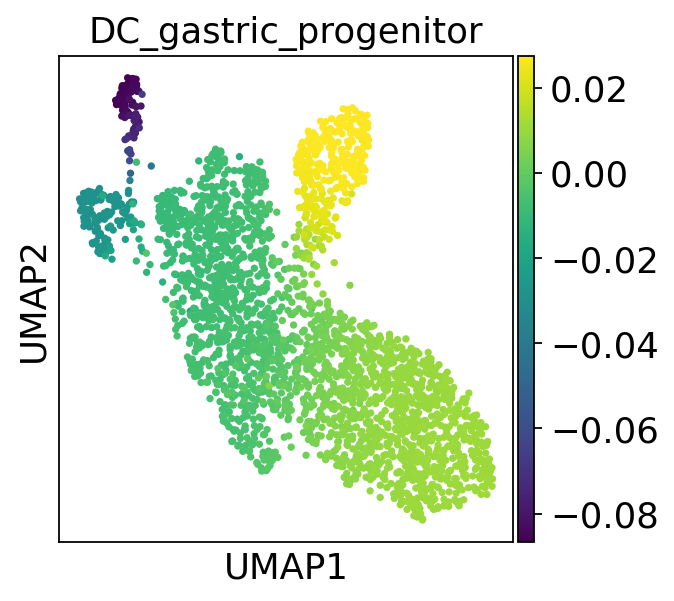

In [ ]:
adata_sub.obs['DC_gastric_progenitor'] = -dm_res['EigenVectors'].to_numpy()[:,2].copy()
sc.pl.umap(adata_sub, color='DC_gastric_progenitor')

Bin gastric-progenitor DC only in gastric or progenitor cells. All other cells will get 0 as their bin value

In [ ]:
DC_bin = np.array([0] * adata_sub.n_obs)
adata_temp = adata_sub[ismember(adata_sub.obs['cell_type'], ['progenitor', 'gastric'])[1],:].copy()
current_DC = adata_temp.obs['DC_gastric_progenitor'].to_numpy()
n_bins = int(len(current_DC) / 100)
breaks = np.quantile(current_DC, np.linspace(start = 0, stop = 1, num=n_bins))
DC_digitized = np.digitize(current_DC, breaks)
DC_digitized[DC_digitized == np.max(DC_digitized)] = DC_digitized[DC_digitized == np.max(DC_digitized)] - 1
DC_bin[ismember(adata_sub.obs_names, adata_temp.obs_names)[1]] = DC_digitized
adata_sub.obs['DC_bin'] = DC_bin
sc.pl.umap(adata_sub, color='DC_bin')
display(adata_sub.obs['DC_bin'].value_counts())

In [ ]:
ismember(adata_sub.obs_names, adata_temp.obs_names)[0]

array([None, 0, None, ..., None, None, None], shape=(2744,), dtype=object)

In [ ]:
sc.write(os.path.join(embedding_output, experiment_prefix + "_BATCH_" + selected_batch + "_SUBSET_K2ctrl__embed.h5ad"), adata = adata_sub)

### Embed batch m3

In [ ]:
selected_batch = "m3"
adata_sub = adata[adata.obs['batch'] == selected_batch,:].copy()
adata_sub

AnnData object with n_obs × n_vars = 6969 × 24776
    obs: 'hash_id', 'original_filename', 'folder', 'prefix', 'mouse_genotype', 'treatment', 'timepoint', 'genotype', 'dox', 'condition', 'replicate_number', 'barcode', 'unclear', 'doublet', 'batch', 'percent_mito', 'percent_ribo', 'replicate_id', 'log_lib_size_raw_all', 'log_lib_size_raw_noExcluded', 'log_detected_raw_all', 'log_detected_raw_noExcluded', 'log_lib_size_cellbender_all', 'log_lib_size_cellbender_noExcluded', 'log_detected_cellbender_all', 'log_detected_cellbender_noExcluded', 'n_counts', 'pheno_30', 'pheno_10', 'hard_threshold_stringent', 'hard_threshold_relax', 'hard_threshold', 'unclear2', 'condition_id', 'archr_valid'
    var: 'excluded'
    obsm: 'X_pca', 'X_umap'
    layers: 'cellbender', 'raw'

Normalizing data
Log transform with pseudocount 1


/data1/lowes/reyesj3/miniconda3/envs/seacells/lib/python3.11/site-packages/scipy/sparse/_construct.py:178: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if len(diagonals) == 0 or isscalarlike(diagonals[0]):


Highly variable gene selection with custom gene exclusion
Selecting 3000 highly variable genes using Scanpy Seurat v3
Using 3000 highly variable genes
Detecting inflection point with average smoothing window of 10 and epsilon 0.000010
Found 49 PCs that explain 0.373517 variance
Fewer than minimum number of PCs. Default to 50 that explain 0.375315 variance
Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.0775294303894043 seconds
Jaccard graph constructed in 1.6897931098937988 seconds
Running Leiden optimization
Leiden completed in 1.9144384860992432 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 4.891407251358032 seconds
Finding 10 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.17638087272644043 seconds
Jaccard graph constructed in 1.0400776863098145 seconds
Running Leiden optimization
Leiden completed in 1.5372867584228516 seconds
Sorting communities by size, please wait

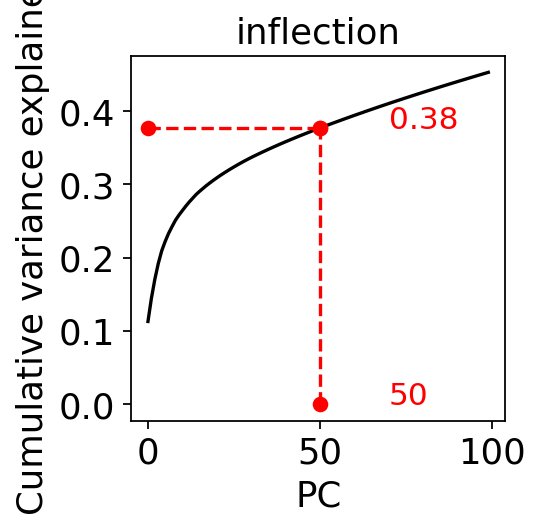

In [ ]:
layer = 'cellbender'
size_factors = 'log_lib_size_%s_all' % (layer)

adata_sub.X = adata_sub.layers['cellbender'].copy()
adata_sub = norm_log_transform(adata_sub, np.expm1(adata_sub.obs[size_factors]), [])
sc.pp.filter_cells(adata_sub, min_counts=1)
sc.pp.filter_genes(adata_sub, min_cells=1)

adata_sub = HVG_selection(adata_sub, num_HVG = 3000, exclude_genes = adata_sub.var['excluded']==True, mode='scanpy', layer='cellbender')
sc.pp.pca(adata_sub, n_comps=100, mask_var='highly_variable')
adata_sub.uns['pca_explained_variance'] = adata_sub.uns['pca']['variance_ratio']
selected_pcs, explained_var = process_pca_results(adata_sub, pca_mode = 'inflection', min_pcs = 50)

sc.pp.neighbors(adata_sub, n_neighbors=30)
sc.tl.umap(adata_sub)

communities = sc.external.tl.phenograph(adata_sub, k=30, clustering_algo = 'leiden', seed = 0, copy=True)
adata_sub.obs['pheno_30'] = pd.Categorical(communities[0])
communities = sc.external.tl.phenograph(adata_sub, k=10, clustering_algo = 'leiden', seed = 0, copy=True)
adata_sub.obs['pheno_10'] = pd.Categorical(communities[0])

In [ ]:
from tqdm import tqdm 

# Z-score and add signature scores
adata_temp = adata_sub.copy()
adata_temp.layers['zscore'] = adata_temp.X.copy()
sc.pp.scale(adata_temp, layer='zscore')
selected_signatures = ['progenitor_specific_0', 'ADM_specific_0', 'gastric_specific_0', 'tuft_specific_30', 'neuroendocrine_specific_0']
signature_names, signature_dict = attach_signatures_low_memory(adata_temp, selected_signatures)

/data1/lowes/reyesj3/miniconda3/envs/seacells/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
  0%|          | 0/238 [00:00<?, ?it/s]/data1/lowes/reyesj3/miniconda3/envs/seacells/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
 15%|█▌        | 36/238 [00:00<00:00, 229.96it/s]/data1/lowes/reyesj3/miniconda3/envs/seacells/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/data1/lowes/reyesj3/miniconda3/envs/seacells/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/data1/lowes/reyesj3/miniconda3/envs/seacells/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies i

/tmp/ipykernel_592733/1067241036.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = adata_temp.obs[selected_signatures + ['pheno_30']].groupby('pheno_30').agg('mean')


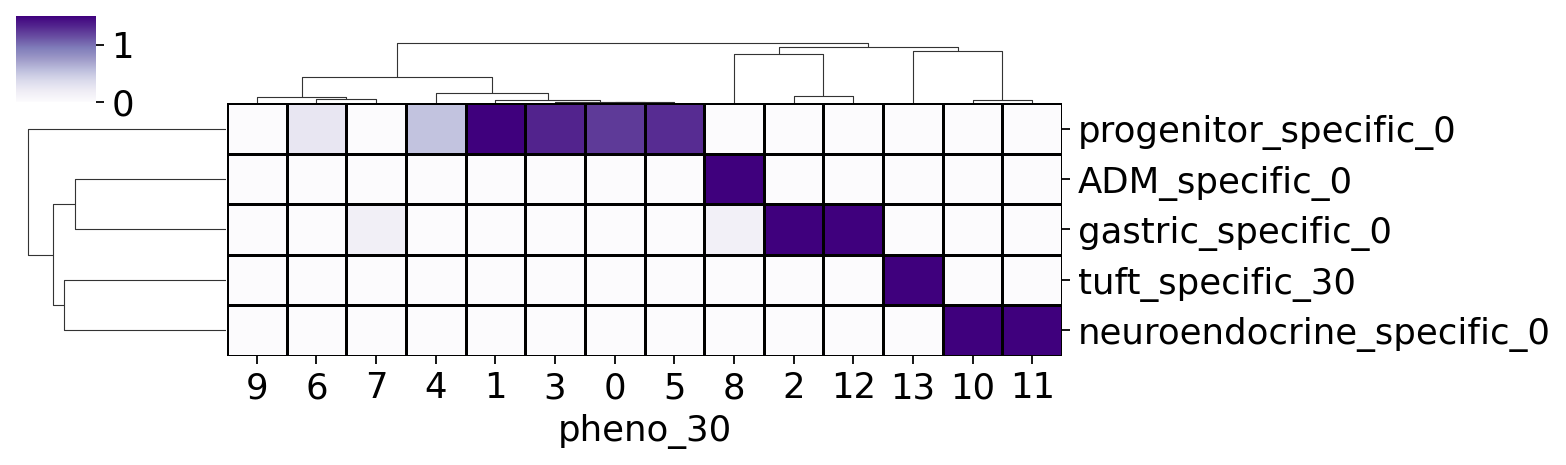

In [ ]:
df = adata_temp.obs[selected_signatures + ['pheno_30']].groupby('pheno_30').agg('mean')
df = df - df.mean(axis=0)
df = df / np.std(df, axis=0)
sns.clustermap(df.T, figsize=[10,3], method='ward', dendrogram_ratio=0.2, cmap='Purples', linewidths = 0.5, vmin=0, vmax=1.5, linecolor='black')
plt.grid(False)

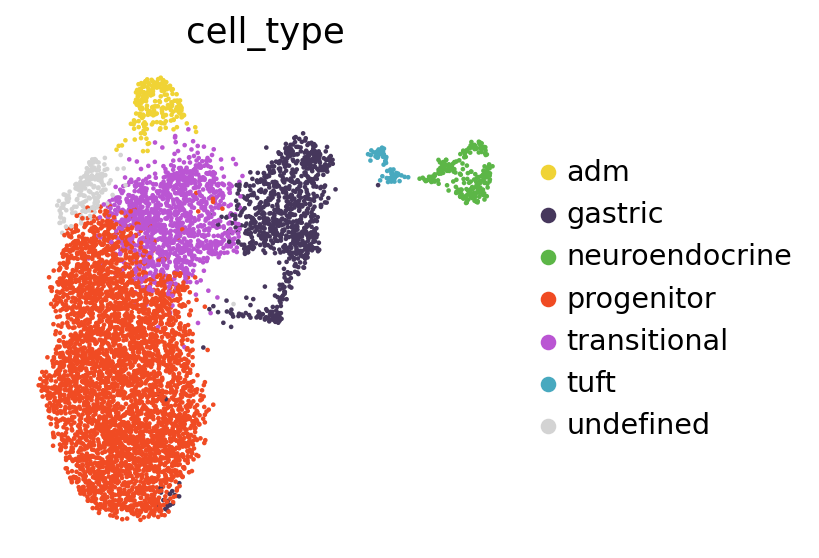

In [ ]:
cell_type = np.array(['undefined'] * adata_sub.n_obs, dtype=object)

# Selected annotation for equalized median size factor version
cell_type[ismember(adata_sub.obs['pheno_30'], [8])[1]] = 'adm'
cell_type[ismember(adata_sub.obs['pheno_30'], [13])[1]] = 'tuft'
cell_type[ismember(adata_sub.obs['pheno_30'], [10,11])[1]] = 'neuroendocrine'
cell_type[ismember(adata_sub.obs['pheno_30'], [1,3,0,5,4])[1]] = 'progenitor'
cell_type[ismember(adata_sub.obs['pheno_30'], [12,2])[1]] = 'gastric'
cell_type[ismember(adata_sub.obs['pheno_30'], [6,7])[1]] = 'transitional'
adata_sub.obs['cell_type'] = cell_type.copy()

cell_type_palette = ['#F0D335', '#46375C', '#5CB647', '#F04B23', "mediumorchid", '#48A9BF', 'lightgray']

sc.pl.umap(adata_sub, color='cell_type', palette = cell_type_palette, frameon=False)

In [ ]:
indices = (adata_sub.obsp['distances'] > 0).astype(np.uint8)
T, _ = get_diffusion_operator_from_knn(indices, adata_sub.obsp['distances'])
dm_res = getDiffusionComponents(T)

adata_sub.obsm['X_diff_comp'] = dm_res['EigenVectors'].to_numpy()[:,1:].copy()
adata_sub.uns['diff_comp_eigenvalues'] = dm_res['EigenValues'].to_numpy()[1:].copy()
adata_sub.obsm['diff_operator'] = dm_res['T'].copy()


Computing diffusion kernel using CPU
Using knn of size 29
Computing diffusion operator using CPU


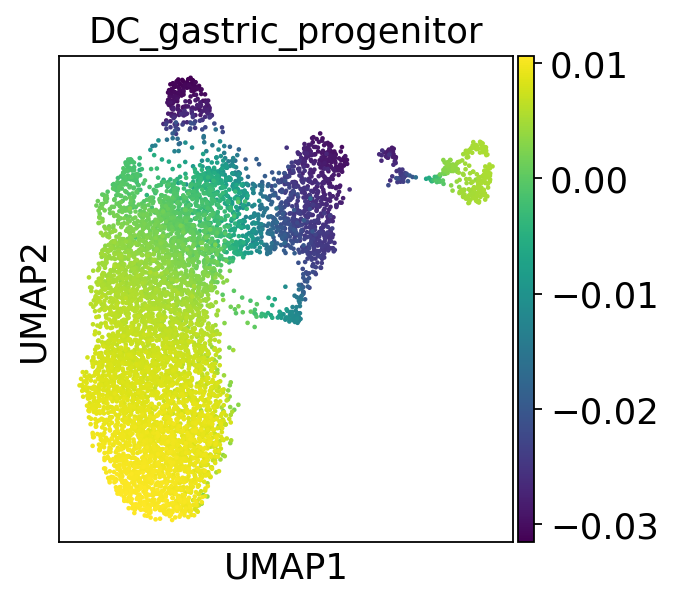

In [ ]:
adata_sub.obs['DC_gastric_progenitor'] = dm_res['EigenVectors'].to_numpy()[:,2].copy()
sc.pl.umap(adata_sub, color='DC_gastric_progenitor')

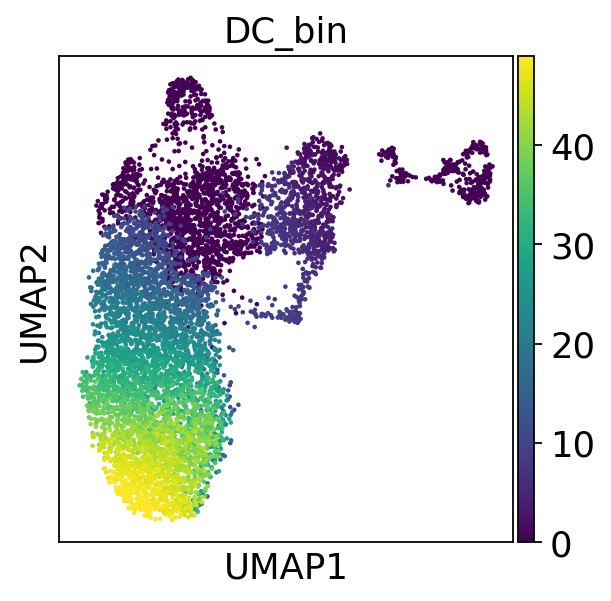

DC_bin
0     1908
23     104
19     104
8      104
34     104
16     104
31     104
27     104
4      104
46     104
1      104
38     104
12     104
49     104
42     104
15     103
21     103
3      103
25     103
48     103
17     103
28     103
5      103
33     103
9      103
39     103
6      103
24     103
43     103
20     103
29     103
18     103
45     103
44     103
22     103
47     103
7      103
14     103
2      103
10     103
32     103
13     103
40     103
11     103
41     103
36     103
37     103
30     103
26     103
35     103
Name: count, dtype: int64

In [ ]:
DC_bin = np.array([0] * adata_sub.n_obs)
adata_temp = adata_sub[ismember(adata_sub.obs['cell_type'], ['progenitor', 'gastric'])[1],:].copy()
current_DC = adata_temp.obs['DC_gastric_progenitor'].to_numpy()
n_bins = int(len(current_DC) / 100)
breaks = np.quantile(current_DC, np.linspace(start = 0, stop = 1, num=n_bins))
DC_digitized = np.digitize(current_DC, breaks)
DC_digitized[DC_digitized == np.max(DC_digitized)] = DC_digitized[DC_digitized == np.max(DC_digitized)] - 1
DC_bin[ismember(adata_sub.obs_names, adata_temp.obs_names)[1]] = DC_digitized
adata_sub.obs['DC_bin'] = DC_bin
sc.pl.umap(adata_sub, color='DC_bin')
display(adata_sub.obs['DC_bin'].value_counts())

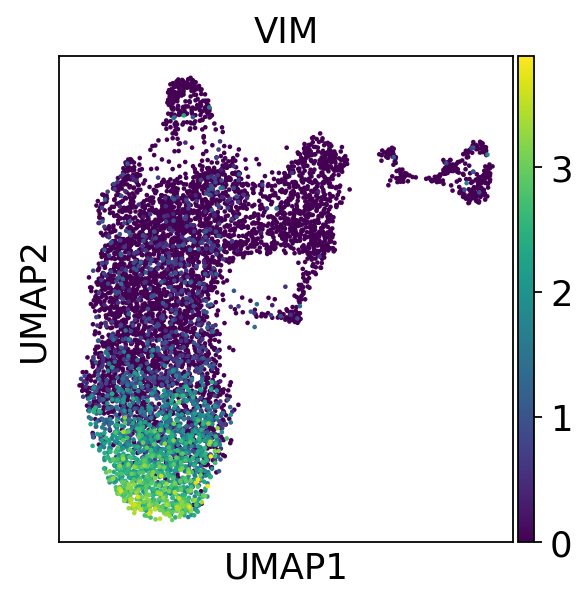

In [ ]:
sc.pl.umap(adata_sub, color='VIM')

In [ ]:
sc.write(os.path.join(embedding_output, experiment_prefix + "_BATCH_" + selected_batch + "_SUBSET_K2ctrl__embed.h5ad"), adata = adata_sub)